# Practice Activity: Text Data - Spam Emails

In this activity you'll work with a small sample from the [Enron email corpus](https://en.wikipedia.org/wiki/Enron_Corpus). The [data set we'll use](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv) contains the subjects and bodies of a sample of e-mails that the Federal Energy Regulatory Commission (FERC) collected during their 2002 investigation of the energy company [Enron](https://en.wikipedia.org/wiki/Enron). Each row in the data set is an email and there are three columns

- subject: the subject of the email
- body: the text of the email
- spam: spam indicator, 1 if spam, 0 if not

For this activity we will only consider the body of the emails (though you could also include the subject using similar methods).

1\. The corpus is the body column in the [data set](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv); read this column in to create the corpus.


In [21]:
import pandas as pd

email_data = pd.read_csv(
    "https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv")

email_data

,subject,body,spam
0,mirant 4 / 01,we invoiced mirant americas for deal 705989 an...,0.0
1,re : lobo payout,because the payback was done for october 2001 ...,0.0
2,entex transaction 7,"for december 1999 , since the volumes for tran...",0.0
3,re : hpl transport contracts,i would think that the first contract should g...,0.0
4,welcome to aol instant messenger !,welcome to the aol instant messenger ( sm ) se...,0.0
...,...,...,...
1985,customer reciept # 4359 bn winkle,simply visti our site and let ' s see if we ca...,NaN
1986,internet pharmacy - smart prices,order your medication here - no doctor visit n...,NaN
1987,victory at last,"wed , 09 jun 2004 13 : 33 : 18 - 0300\nsir or ...",NaN
1988,free pay per view,had chance at last to view the warner bros . l...,NaN


In [22]:
corpus = email_data["body"]

corpus

,body
0,we invoiced mirant americas for deal 705989 an...
1,because the payback was done for october 2001 ...
2,"for december 1999 , since the volumes for tran..."
3,i would think that the first contract should g...
4,welcome to the aol instant messenger ( sm ) se...
...,...
1985,simply visti our site and let ' s see if we ca...
1986,order your medication here - no doctor visit n...
1987,"wed , 09 jun 2004 13 : 33 : 18 - 0300\nsir or ..."
1988,had chance at last to view the warner bros . l...


2\. Describe in words in detail the steps that you would take to clean the emails and create the term-frequency matrix. We will write the code in the next part, but think carefully first about the process: how do we turn this text into tabular data?


First, I would treat each email body as one document and the entire body column as the corpus. I would then clean and tokenize the text by converting words to lowercase, removing punctuation, and separating each email into individual terms. Next, I would count how many times each term appears in each email. Then, I would organize the results into a term-frequency matrix where each row represents an email, each column represents a unique term, and each value represents the number of times that term appears in that email.

3\. Use `CountVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `CountVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.


In [23]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = email_data["body"].fillna("")

vec = CountVectorizer()
vec.fit(corpus)

tf_matrix = vec.transform(corpus)

tf_df = pd.DataFrame(
    tf_matrix.todense(),
    columns=vec.get_feature_names_out(),
    index=email_data.index)

tf_df

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1986,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1987,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1988,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


4\. Explain what a document frequency (DF) is, and the idea of an IDF. Why might we use TF-IDF rather than just TF? This question is asking about concepts rather than computations.


Document frequency (DF) is the number of documents in the corpus that contain a particular term at least once. It's different from term frequency (TF), which counts how many times a term appears within a particular document. TF-IDF combines a term’s frequency within a document with its importance across the corpus. We might use TF-IDF rather than only TF because TF-IDF reduces the influence of very common terms and emphasizes terms that are more useful for distinguishing one email from another.

5\. Use `TfidfVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `TfidfVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer()
tfidf_vec.fit(corpus)

tfidf_matrix = tfidf_vec.transform(corpus)

tfidf_df = pd.DataFrame(
    tfidf_matrix.todense(),
    columns=tfidf_vec.get_feature_names_out(),
    index=email_data.index
)

tfidf_df

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0.0,0.106624,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2,0.0,0.097060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11587,0.0
1986,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1987,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1988,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0


6\. Remember that the data set also contains an indicator of whether or not the email is spam. In this part you will use descriptive statistics and plots to compare the spam and non-spam emails in terms of their text, represented by the TF and TF-IDF matrices. This part is pretty open ended. First brainstorm some questions or things to investigate, and then write the code to produce relevant summaries.

Note: there are 10 emails for which the spam indicator is missing. You should remove them for this part. We'll come back to them soon.


I will compare the number of spam and non spam emails, their average word counts, their most frequent terms based on TF, and the terms with the highest average TF-IDF weights. These comparisons may show whether spam emails differ in length and vocabulary from non spam emails.

In [25]:
known_emails = email_data.dropna(subset=["spam"])

known_tf = tf_df.loc[known_emails.index]
known_tfidf = tfidf_df.loc[known_emails.index]

known_emails["spam"].value_counts()

,count
spam,
0.0,995
1.0,985


In [26]:
email_summary = pd.DataFrame({
    "spam": known_emails["spam"],
    "word_count": known_tf.sum(axis=1)
})

email_summary.groupby("spam")["word_count"].mean()

,word_count
spam,
0.0,135.327638
1.0,176.189848


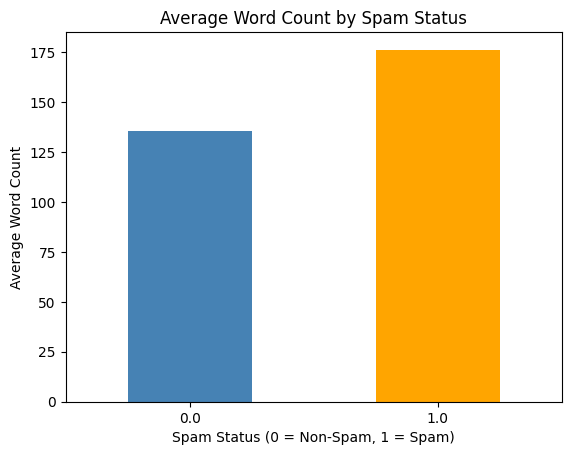

In [27]:
import matplotlib.pyplot as plt

email_summary.groupby("spam")["word_count"].mean().plot(
    kind="bar",
    color=["steelblue", "orange"]
)

plt.title("Average Word Count by Spam Status")
plt.xlabel("Spam Status (0 = Non-Spam, 1 = Spam)")
plt.ylabel("Average Word Count")
plt.xticks(rotation=0)
plt.show()

In [28]:
spam_tf = known_tf.loc[known_emails["spam"] == 1].mean()
nonspam_tf = known_tf.loc[known_emails["spam"] == 0].mean()

spam_tf.sort_values(ascending=False).head(10)

,0
the,4.888325
to,3.524873
and,3.394924
of,3.084264
in,2.095431
you,1.854822
for,1.678173
this,1.559391
is,1.469036
your,1.233503


In [29]:
spam_tfidf = known_tfidf.loc[known_emails["spam"] == 1].mean()
nonspam_tfidf = known_tfidf.loc[known_emails["spam"] == 0].mean()

spam_tfidf.sort_values(ascending=False).head(10)

,0
the,0.057534
to,0.050273
and,0.049189
you,0.042117
of,0.040379
your,0.034473
in,0.029420
for,0.028624
is,0.025543
this,0.024971


In [30]:
print("Top TF terms in non-spam emails:")
display(
    nonspam_tf.sort_values(ascending=False).head(10)
)

print("Top TF-IDF terms in non-spam emails:")
display(
    nonspam_tfidf.sort_values(ascending=False).head(10)
)

Top TF terms in non-spam emails:


,0
the,4.795980
to,3.958794
ect,3.634171
and,1.950754
hou,1.913568
for,1.875377
enron,1.609045
on,1.547739
of,1.468342
this,1.300503


Top TF-IDF terms in non-spam emails:


,0
the,0.082967
ect,0.075379
to,0.065038
enron,0.051935
hou,0.040775
xls,0.040757
for,0.038417
000,0.036508
on,0.035399
and,0.034985


There were 995 non-spam emails and 985 spam emails. Spam emails were longer on average, with about 176 words compared with 135 words for non-spam emails. The TF and TF-IDF results contained many common words, but words such as “you” and “your” were prominent in spam emails. These differences may help identify spam.

7\. Now consider the 10 emails for which the true spam status is unknown. How might you decide if each email is spam or not? Brainstorm some ideas before proceeding. How can you use the TF and TF-IDF matrices for emails with known spam status?

I would compare each unknown email’s TF or TF-IDF representation with the emails whose spam statuses are known. I would find the most similar known emails and examine whether they are mostly spam or non-spam. If most of the closest emails are spam, I would classify the unknown email as spam, and vice versa.

8\. Consider just one email with unknown spam status, with `loc` 1980. Compute the cosine distance between the TF representation of this email and the TF representation of each of the emails with known spam status.

In [31]:
from sklearn.metrics.pairwise import cosine_distances

unknown_tf = tf_df.loc[[1980]]

distances = cosine_distances(unknown_tf, known_tf)[0]

tf_distances = pd.DataFrame({
    "distance": distances,
    "spam": known_emails["spam"].values
}, index=known_tf.index)

tf_distances

,distance,spam
0,0.736928,0.0
1,0.542990,0.0
2,0.775802,0.0
3,0.653954,0.0
4,0.519088,0.0
...,...,...
1975,0.944996,1.0
1976,0.649040,1.0
1977,0.448669,1.0
1978,0.693219,1.0


9\. Sort the results of the previous part to examine the emails with known spam status that are most similar to the unknown email. If you had to determine if the unknown email was spam or not, which would you pick and why?

In [32]:
closest_tf = tf_distances.sort_values("distance").head(10)

closest_tf

,distance,spam
1889,0.393060,1.0
1032,0.398488,1.0
1376,0.408606,1.0
714,0.414644,0.0
1110,0.415807,1.0
26,0.418573,0.0
180,0.423172,0.0
879,0.424620,0.0
713,0.427930,0.0
139,0.434841,0.0


In [33]:
closest_tf["spam"].value_counts()

,count
spam,
0.0,6
1.0,4


10\. Repeat the two previous parts using TF-IDF instead of TF. Do the results change?

In [34]:
unknown_tfidf = tfidf_df.loc[[1980]]

tfidf_distance_values = cosine_distances(
    unknown_tfidf,
    known_tfidf
)[0]

tfidf_distances = pd.DataFrame({
    "distance": tfidf_distance_values,
    "spam": known_emails["spam"].values
}, index=known_tfidf.index)

closest_tfidf = tfidf_distances.sort_values("distance").head(10)

closest_tfidf

,distance,spam
1032,0.755245,1.0
1977,0.780917,1.0
48,0.787975,0.0
1689,0.790205,1.0
1796,0.795094,1.0
180,0.797415,0.0
586,0.798537,0.0
1376,0.799377,1.0
279,0.799969,0.0
1021,0.801259,1.0


In [35]:
closest_tfidf["spam"].value_counts()

,count
spam,
1.0,6
0.0,4


In [36]:
print("TF results:")
display(closest_tf["spam"].value_counts())

print("TF-IDF results:")
display(closest_tfidf["spam"].value_counts())

TF results:


,count
spam,
0.0,6
1.0,4


TF-IDF results:


,count
spam,
1.0,6
0.0,4


11\. Now proceed in a similar manner to "guess" the spam status of each of the unknown emails.

In [37]:
unknown_locs = email_data[email_data["spam"].isna()].index

for loc in unknown_locs:

    distances = cosine_distances(
        tfidf_df.loc[[loc]],
        known_tfidf
    )[0]

    results = pd.DataFrame({
        "distance": distances,
        "spam": known_emails["spam"].values
    })

    closest_five = results.sort_values("distance").head(5)

    print("Unknown email:", loc)
    print(closest_five["spam"].value_counts())
    print()

    predictions = pd.DataFrame({
    "email": [1980, 1981, 1982, 1983, 1984,
              1985, 1986, 1987, 1988, 1989],

    "predicted_spam": [1, 0, 0, 0, 0,
                       1, 1, 1, 1, 0]
})

predictions

Unknown email: 1980
spam
1.0    4
0.0    1
Name: count, dtype: int64

Unknown email: 1981
spam
0.0    5
Name: count, dtype: int64

Unknown email: 1982
spam
0.0    4
1.0    1
Name: count, dtype: int64

Unknown email: 1983
spam
0.0    5
Name: count, dtype: int64

Unknown email: 1984
spam
0.0    5
Name: count, dtype: int64

Unknown email: 1985
spam
1.0    4
0.0    1
Name: count, dtype: int64

Unknown email: 1986
spam
1.0    5
Name: count, dtype: int64

Unknown email: 1987
spam
1.0    5
Name: count, dtype: int64

Unknown email: 1988
spam
1.0    5
Name: count, dtype: int64

Unknown email: 1989
spam
0.0    3
1.0    2
Name: count, dtype: int64



,email,predicted_spam
0,1980,1
1,1981,0
2,1982,0
3,1983,0
4,1984,0
5,1985,1
6,1986,1
7,1987,1
8,1988,1
9,1989,0


Using the majority status among the five closest emails, I predicted emails 1980, 1985, 1986, 1987, and 1988 as spam. I predicted emails 1981, 1982, 1983, 1984, and 1989 as non spam.